# GTSRB German Traffic Sign Recognition Benchmark

This notebook builds a traffic sign classifier using the GTSRB dataset. It starts with dataset download, trains a CNN from scratch, improves the approach using EfficientNetB0 transfer learning, fine-tunes the model, evaluates saved models, and prepares the final Streamlit deployment files.



### 📥 Step 1 — Download the GTSRB Dataset from Kaggle
Sets up Kaggle API credentials, downloads the GTSRB dataset ZIP, unzips it to the working directory, and lists the contents to confirm the download succeeded.

In [2]:
import os
import tensorflow as tf

# 1. Kaggle credentials
os.environ['KAGGLE_USERNAME'] = 'Omar/Essam/20'
os.environ['KAGGLE_KEY'] = 'YOUR_KAGGLE_API_KEY'

# 2. Define path
base_path = '/content/gtsrb-german-traffic-sign'
os.makedirs(base_path, exist_ok=True)

# 3. Download GTSRB dataset
!kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign --force

# 4. Unzip dataset
!unzip -nq gtsrb-german-traffic-sign.zip -d {base_path}

# 5. Check files
!ls {base_path}

Dataset URL: https://www.kaggle.com/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
License(s): CC0-1.0
100% 612M/612M [00:07<00:00, 86.7MB/s]

meta  Meta  Meta.csv  test  Test  Test.csv  train  Train  Train.csv


### 🗂️ Step 2 — Verify Dataset Structure
Checks the top-level dataset directory and counts the number of class folders inside `Train/`. There should be **43 classes** corresponding to the 43 traffic sign categories.

In [3]:
import os

base_path = "/content/gtsrb-german-traffic-sign"
train_path = os.path.join(base_path, "Train")

print(os.listdir(base_path))
print("Number of classes:", len(os.listdir(train_path)))

['Train.csv', 'Meta.csv', 'train', 'meta', 'Meta', 'test', 'Test', 'Test.csv', 'Train']
Number of classes: 43


# Load data for CNN from scratch

### 📂 Step 3 — Load Training & Validation Datasets (32×32 for CNN from Scratch)
Uses `image_dataset_from_directory` to load images resized to **32×32** pixels with a **90/10 train-validation split**. Integer labels are inferred from subdirectory names. `num_classes` is extracted from the class list.

In [4]:
import tensorflow as tf

IMG_SIZE = (32, 32)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="int",
    validation_split=0.1,
    subset="training",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="int",
    validation_split=0.1,
    subset="validation",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED
)

class_names = train_ds.class_names
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

Found 39209 files belonging to 43 classes.
Using 35289 files for training.
Found 39209 files belonging to 43 classes.
Using 3920 files for validation.
Classes: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '5', '6', '7', '8', '9']
Number of classes: 43


### improve loading speed

### ⚡ Step 4 — Optimise the Data Pipeline
Applies `.cache()`, `.shuffle()`, and `.prefetch(AUTOTUNE)` to the datasets. Caching stores decoded images in RAM after the first epoch so subsequent epochs load instantly. Prefetching overlaps data loading with GPU computation to eliminate idle time.

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

### 🖼️ Step 5 — Visualise Sample Training Images
Plots a 3×3 grid of random images from the first training batch with their class labels. This sanity-checks that images and labels are correctly aligned before training begins.

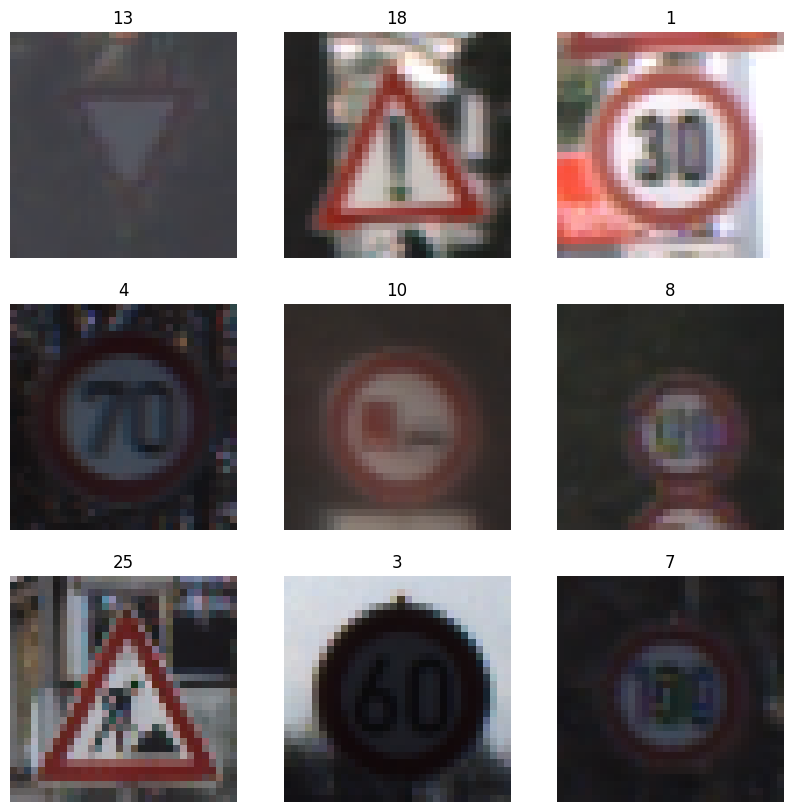

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

## Building CNN

### 📦 Step 6 — Import Keras Layers and Model Classes
Imports the necessary building blocks from TensorFlow/Keras for constructing the CNN architecture.

In [7]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model,Sequential

### 🏗️ Step 7 — Define the CNN Architecture (From Scratch)
Builds a 3-block convolutional network:
- **Block 1–3:** Conv2D → BatchNormalization → MaxPooling2D (filters: 32 → 64 → 128)
- **Head:** Flatten → Dense(256, ReLU) → Dropout(0.5) → Dense(43, Softmax)

BatchNorm stabilises training. Dropout prevents overfitting. The model is compiled with Adam and `sparse_categorical_crossentropy` (integer labels).

In [8]:
from tensorflow.keras import layers, models

scratch_model = models.Sequential([

    # Normalize pixel values from range [0, 255] to [0, 1]
    layers.Input(shape=(32, 32, 3)),
    layers.Rescaling(1./255),

    # First convolution block
    # Conv2D extracts simple features such as edges and corners
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),

    # BatchNormalization stabilizes and speeds up training
    layers.BatchNormalization(),

    # MaxPooling reduces image size and keeps important features
    layers.MaxPooling2D(),

    # Second convolution block
    # Extracts more complex features from the previous layer
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Third convolution block
    # Learns deeper patterns related to traffic sign shapes and symbols
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    # Convert feature maps into a 1D vector before Dense layers
    layers.Flatten(),

    # Fully connected layer for final feature learning
    layers.Dense(256, activation="relu"),

    # Dropout reduces overfitting by randomly disabling 50% of neurons
    layers.Dropout(0.5),

    # Output layer
    # Number of neurons = number of traffic sign classes
    # Softmax gives probability for each class
    layers.Dense(num_classes, activation="softmax")
])

# Compile the model
# Adam optimizer updates weights during training
# sparse_categorical_crossentropy is used because labels are integer encoded
scratch_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Display model architecture and number of parameters
scratch_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 629,739 (2.40 MB)

 Trainable params: 629,291 (2.40 MB)

 Non-trainable params: 448 (1.75 KB)

### 🏋️ Train the CNN from Scratch

### 🏋️ Step 8 — Train the CNN from Scratch
Trains the model for **10 epochs** on the training dataset with validation after each epoch. Training and validation accuracy/loss are recorded in `history_scratch`.

In [9]:
history_scratch = scratch_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accuracy: 0.6702 - loss: 1.1547 - val_accuracy: 0.9474 - val_loss: 0.1725
Epoch 2/10
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 23s 5ms/step - accuracy: 0.9468 - loss: 0.1686 - val_accuracy: 0.9765 - val_loss: 0.0779
Epoch 3/10
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9651 - loss: 0.1101 - val_accuracy: 0.9898 - val_loss: 0.0325
Epoch 4/10
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9721 - loss: 0.0957 - val_accuracy: 0.9714 - val_loss: 0.0938
Epoch 5/10
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9803 - loss: 0.0670 - val_accuracy: 0.9776 - val_loss: 0.0901
Epoch 6/10
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9808 - loss: 0.0684 - val_accuracy: 0.9926 - val_loss: 0.0317
Epoch 7/10
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9838 - loss: 0.0601 - val_accuracy: 0.9885 - val_loss: 0.0355
Epoch 8/10
1103/1103 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9869 - loss: 0.0489

### 📊 Step 9 — Plot CNN Training Curves
Plots accuracy and loss curves for both training and validation sets across all epochs. These curves reveal whether the model is underfitting, overfitting, or converging well.

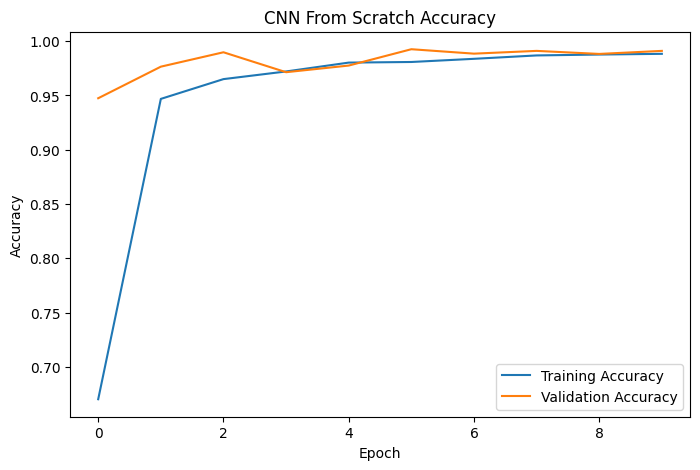

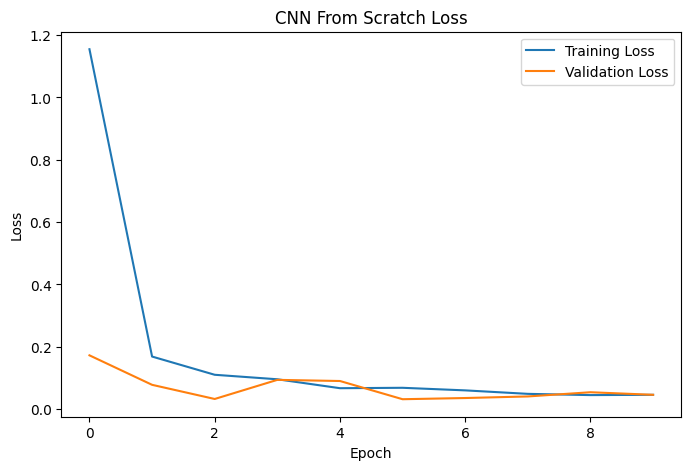

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(history_scratch.history["accuracy"], label="Training Accuracy")
plt.plot(history_scratch.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("CNN From Scratch Accuracy")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_scratch.history["loss"], label="Training Loss")
plt.plot(history_scratch.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("CNN From Scratch Loss")
plt.show()

### 💾 Step 10 — Save the Scratch CNN Model
Saves the trained CNN to disk in Keras format. This checkpoint can be reloaded later for evaluation or comparison without retraining.

In [11]:
scratch_model.save("scratch_cnn_gtsrb.keras")

#  Re-load data at 224x224 for transfer learning


### TRANSFER LEARNING

### 📂 Step 11 — Reload Dataset at 224×224 for Transfer Learning
EfficientNetB0 requires **224×224** input images. The dataset is reloaded at this larger resolution with a smaller batch size of **16** to avoid GPU memory overflow. Data augmentation (random rotation, zoom, contrast) is defined inline and applied during training only.

In [12]:
import os
import tensorflow as tf
from tensorflow.keras import layers, callbacks

base_path = "/content/gtsrb-german-traffic-sign"
train_path = os.path.join(base_path, "Train")

IMG_SIZE_TL = (224, 224)
BATCH_SIZE = 16
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

train_ds_tl = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="int",
    validation_split=0.1,
    subset="training",
    image_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_ds_tl = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="int",
    validation_split=0.1,
    subset="validation",
    image_size=IMG_SIZE_TL,
    batch_size=BATCH_SIZE,
    seed=SEED
)

class_names = train_ds_tl.class_names
num_classes = len(class_names)

print("Number of classes:", num_classes)

train_ds_tl = train_ds_tl.shuffle(500).prefetch(AUTOTUNE)
val_ds_tl = val_ds_tl.prefetch(AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

tl_model = tf.keras.Model(inputs, outputs, name="EfficientNetB0_TransferLearning")

tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

tl_model.summary()

cb_tl = [
    callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    ),
    callbacks.ModelCheckpoint(
        "tl_model_best.keras",
        monitor="val_accuracy",
        save_best_only=True
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    )
]

history_tl = tl_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=20,
    callbacks=cb_tl
)

Found 39209 files belonging to 43 classes.
Using 35289 files for training.
Found 39209 files belonging to 43 classes.
Using 3920 files for validation.
Number of classes: 43
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,393,678 (16.76 MB)

 Trainable params: 341,547 (1.30 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

Epoch 1/20
2206/2206 ━━━━━━━━━━━━━━━━━━━━ 141s 53ms/step - accuracy: 0.6830 - loss: 1.0509 - val_accuracy: 0.8847 - val_loss: 0.3434 - learning_rate: 0.0010
Epoch 2/20
2206/2206 ━━━━━━━━━━━━━━━━━━━━ 121s 51ms/step - accuracy: 0.7941 - loss: 0.6241 - val_accuracy: 0.9130 - val_loss: 0.2565 - learning_rate: 0.0010
Epoch 3/20
2206/2206 ━━━━━━━━━━━━━━━━━━━━ 120s 52ms/step - accuracy: 0.8212 - loss: 0.5449 - val_accuracy: 0.9276 - val_loss: 0.2073 - learning_rate: 0.0010
Epoch 4/20
2206/2206 ━━━━━━━━━━━━━━━━━━━━ 121s 52ms/step - accuracy: 0.8356 - loss: 0.4993 - val_accuracy: 0.9370 - val_loss: 0.1940 - learning_rate: 0.0010
Epoch 5/20
2206/2206 ━━━━━━━━━━━━━━━━━━━━ 120s 52ms/step - accuracy: 0.8494 - loss: 0.4671 - val_accuracy: 0.9528 - val_loss: 0.1541 - learning_rate: 0.0010
Epoch 6/20
2206/2206 ━━━━━━━━━━━━━━━━━━━━ 120s 52ms/step - accuracy: 0.8579 - loss: 0.4398 - val_accuracy: 0.9508 - val_loss: 0.1574 - learning_rate: 0.0010
Epoch 7/20
2206/2206 ━━━━━━━━━━━━━━━━━━━━ 120s 52ms/step -

### 📊 Step 12 — Train Transfer Learning Model & Plot Results
Freezes the EfficientNetB0 base and trains only the new classification head for up to **20 epochs**. Uses `EarlyStopping`, `ModelCheckpoint`, and `ReduceLROnPlateau` callbacks. Then plots accuracy and loss curves for both phases.

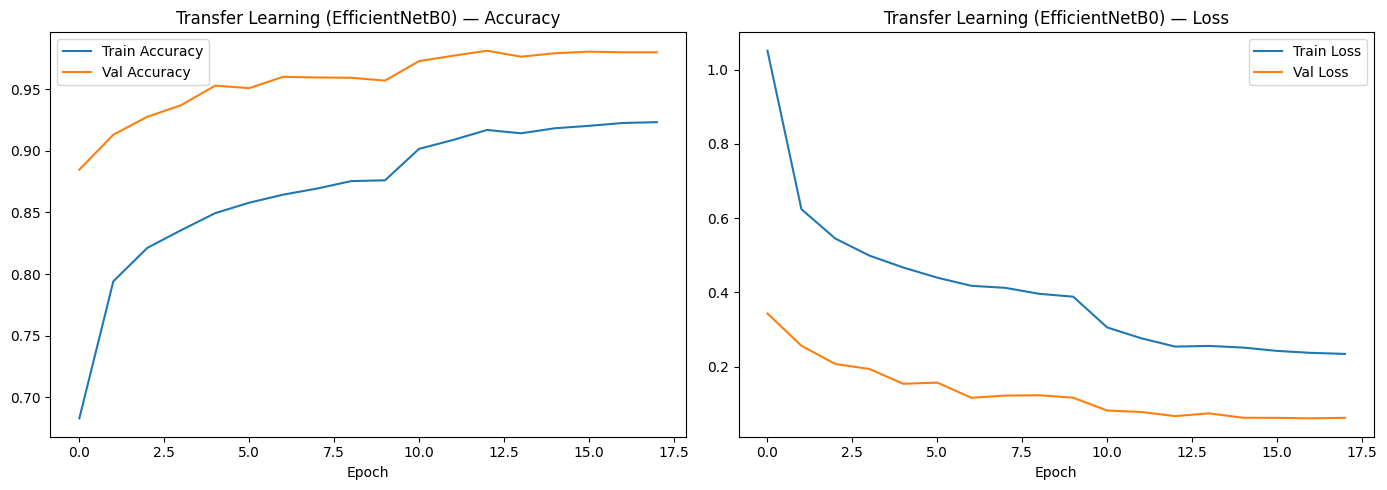

In [13]:
# ============================================================
#  Plot Transfer Learning Results
# ============================================================
import matplotlib.pyplot as plt

def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.plot(history.history["accuracy"],     label="Train Accuracy")
    ax1.plot(history.history["val_accuracy"], label="Val Accuracy")
    ax1.set_title(f"{title} — Accuracy")
    ax1.set_xlabel("Epoch"); ax1.legend()

    ax2.plot(history.history["loss"],     label="Train Loss")
    ax2.plot(history.history["val_loss"], label="Val Loss")
    ax2.set_title(f"{title} — Loss")
    ax2.set_xlabel("Epoch"); ax2.legend()
    plt.tight_layout(); plt.show()

plot_history(history_tl, "Transfer Learning (EfficientNetB0)")

# Fine-Tuning

### 🔓 Step 13 — Fine-Tune EfficientNetB0 (Top 30 Layers Unfrozen)
Loads the best transfer learning checkpoint. Locates the EfficientNetB0 sub-model by iterating layer names, unfreezes it, then re-freezes all layers **except the last 30**. Recompiles with a much smaller learning rate (**1e-5**) to avoid destroying pretrained weights. Trains for up to 20 more epochs.

Trainable layers after unfreezing top 30: 8
Epoch 1/20
2206/2206 ━━━━━━━━━━━━━━━━━━━━ 160s 63ms/step - accuracy: 0.7837 - loss: 0.7623 - val_accuracy: 0.9485 - val_loss: 0.1760 - learning_rate: 1.0000e-05
Epoch 2/20
2206/2206 ━━━━━━━━━━━━━━━━━━━━ 142s 62ms/step - accuracy: 0.8455 - loss: 0.4999 - val_accuracy: 0.9630 - val_loss: 0.1258 - learning_rate: 1.0000e-05
Epoch 3/20
2206/2206 ━━━━━━━━━━━━━━━━━━━━ 142s 62ms/step - accuracy: 0.8766 - loss: 0.3890 - val_accuracy: 0.9730 - val_loss: 0.0916 - learning_rate: 1.0000e-05
Epoch 4/20
2206/2206 ━━━━━━━━━━━━━━━━━━━━ 151s 66ms/step - accuracy: 0.8928 - loss: 0.3315 - val_accuracy: 0.9747 - val_loss: 0.0790 - learning_rate: 1.0000e-05
Epoch 5/20
2206/2206 ━━━━━━━━━━━━━━━━━━━━ 141s 62ms/step - accuracy: 0.9021 - loss: 0.3000 - val_accuracy: 0.9773 - val_loss: 0.0686 - learning_rate: 1.0000e-05
Epoch 6/20
2206/2206 ━━━━━━━━━━━━━━━━━━━━ 153s 66ms/step - accuracy: 0.9112 - loss: 0.2691 - val_accuracy: 0.9788 - val_loss: 0.0609 - learning_rate: 1

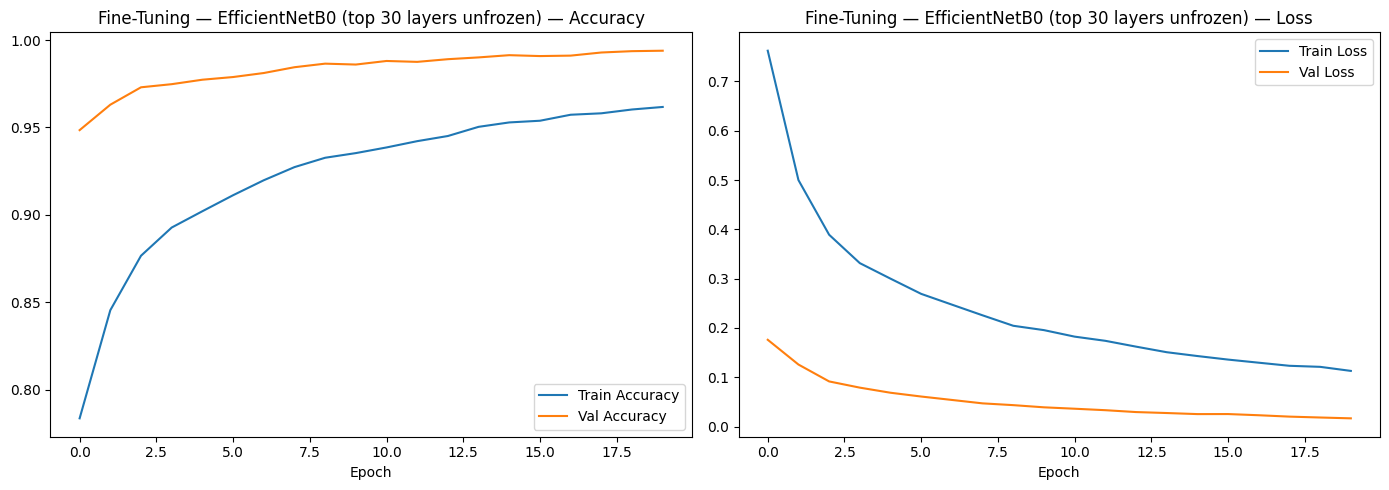

In [14]:

# Load the best TL checkpoint before fine-tuning
tl_model = tf.keras.models.load_model("tl_model_best.keras")

# Find the EfficientNetB0 layer inside the model
efficientnet_layer = None
for layer in tl_model.layers:
    if "efficientnetb0" in layer.name:
        efficientnet_layer = layer
        break

if efficientnet_layer is None:
    raise ValueError("Could not find EfficientNetB0 layer. Check tl_model.summary().")

# Unfreeze base model
efficientnet_layer.trainable = True

# Freeze everything EXCEPT the last 30 layers of the base
for layer in efficientnet_layer.layers[:-30]:
    layer.trainable = False

total_trainable = sum(1 for l in tl_model.layers if l.trainable)
print(f"Trainable layers after unfreezing top 30: {total_trainable}")

# CRITICAL: use a much smaller LR for fine-tuning — large LR destroys pretrained weights
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

cb_ft = [
    callbacks.EarlyStopping(monitor="val_accuracy", patience=7, restore_best_weights=True),
    callbacks.ModelCheckpoint("finetuned_model_best.keras", monitor="val_accuracy", save_best_only=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, verbose=1)
]

history_ft = tl_model.fit(
    train_ds_tl,
    validation_data=val_ds_tl,
    epochs=20,
    callbacks=cb_ft
)

plot_history(history_ft, "Fine-Tuning — EfficientNetB0 (top 30 layers unfrozen)")

### 📏 Step 14 — Evaluate All Three Models on the Test Set
Loads the CSV-based test set (not folder-structured) and builds custom `tf.data` pipelines at both 32×32 and 224×224 resolutions. Evaluates all three saved models and prints a side-by-side accuracy comparison table. Also saves `class_names.json` for use in the web app.

In [15]:
# ============================================================
# Evaluate All 3 Models on Test Set - Memory Safe Version
# ============================================================

import os
import json
import pandas as pd
import tensorflow as tf

base_path = "/content/gtsrb-german-traffic-sign"
test_csv_path = os.path.join(base_path, "Test.csv")

test_df = pd.read_csv(test_csv_path)

print(test_df.head())
print("Test images:", len(test_df))

test_paths = [os.path.join(base_path, p) for p in test_df["Path"].values]
test_labels = test_df["ClassId"].values

def make_test_dataset(img_size, batch_size):
    path_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))

    def load_image(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_png(image, channels=3)
        image = tf.image.resize(image, img_size)
        return image, label

    ds = path_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

test_ds_32 = make_test_dataset((32, 32), 32)
test_ds_224 = make_test_dataset((224, 224), 16)

scratch_model = tf.keras.models.load_model("scratch_cnn_gtsrb.keras")
tl_model_eval = tf.keras.models.load_model("tl_model_best.keras")
ft_model = tf.keras.models.load_model("finetuned_model_best.keras")

scratch_loss, acc_scratch = scratch_model.evaluate(test_ds_32, verbose=1)
tl_loss, acc_tl = tl_model_eval.evaluate(test_ds_224, verbose=1)
ft_loss, acc_ft = ft_model.evaluate(test_ds_224, verbose=1)

print("\n" + "="*60)
print(f"{'Model':<40} {'Test Accuracy':>15}")
print("="*60)
print(f"{'CNN from Scratch':<40} {acc_scratch*100:>14.2f}%")
print(f"{'EfficientNetB0 Transfer Learning':<40} {acc_tl*100:>14.2f}%")
print(f"{'EfficientNetB0 Fine-Tuned':<40} {acc_ft*100:>14.2f}%")
print("="*60)

class_names = [str(i) for i in range(43)]

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("\nSaved class_names.json")

   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId            Path
0     53      54       6       5      48      49       16  Test/00000.png
1     42      45       5       5      36      40        1  Test/00001.png
2     48      52       6       6      43      47       38  Test/00002.png
3     27      29       5       5      22      24       33  Test/00003.png
4     60      57       5       5      55      52       11  Test/00004.png
Test images: 12630
395/395 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.0632 - loss: 60.8518
790/790 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - accuracy: 0.0462 - loss: 31.5191
790/790 ━━━━━━━━━━━━━━━━━━━━ 40s 44ms/step - accuracy: 0.0530 - loss: 42.9942

Model                                      Test Accuracy
CNN from Scratch                                   6.32%
EfficientNetB0 Transfer Learning                   4.62%
EfficientNetB0 Fine-Tuned                          5.30%

Saved class_names.json


### ⬇️ Step 15 — Download Best Model and Class Names
Downloads `finetuned_model_best.keras` and `class_names.json` from the Colab environment to your local machine. These two files are required to run the Streamlit web app.

In [16]:

from google.colab import files

files.download("finetuned_model_best.keras")
files.download("class_names.json")
print("Downloaded! Put both files in the same folder as app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded! Put both files in the same folder as app.py


### 📦 Step 16 — Install Streamlit and Pyngrok (for Colab Preview)
Installs `streamlit` and `pyngrok` so the app can be tunnelled and previewed directly from a Colab session if needed.

In [18]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 65.0 MB/s eta 0:00:00


### 🚦 Step 17 — Streamlit App Source (Full Version)
Contains the full production-ready Streamlit app code. This version explicitly applies EfficientNet's `preprocess_input` to ensure pixel values are scaled correctly for the fine-tuned model. Displays the uploaded image alongside the top-3 predictions and confidence progress bars.

In [25]:
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
from pathlib import Path
from tensorflow.keras.applications.efficientnet import preprocess_input

st.set_page_config(
    page_title="Traffic Sign Classifier",
    page_icon="🚦",
    layout="centered"
)

MODEL_PATH = Path(__file__).parent / "finetuned_model_best.keras"

SIGN_NAMES = {
    0: "Speed limit (20km/h)",
    1: "Speed limit (30km/h)",
    2: "Speed limit (50km/h)",
    3: "Speed limit (60km/h)",
    4: "Speed limit (70km/h)",
    5: "Speed limit (80km/h)",
    6: "End of speed limit (80km/h)",
    7: "Speed limit (100km/h)",
    8: "Speed limit (120km/h)",
    9: "No passing",
    10: "No passing for vehicles over 3.5 tons",
    11: "Right-of-way at next intersection",
    12: "Priority road",
    13: "Yield",
    14: "Stop",
    15: "No vehicles",
    16: "Vehicles over 3.5 tons prohibited",
    17: "No entry",
    18: "General caution",
    19: "Dangerous curve left",
    20: "Dangerous curve right",
    21: "Double curve",
    22: "Bumpy road",
    23: "Slippery road",
    24: "Road narrows on the right",
    25: "Road work",
    26: "Traffic signals",
    27: "Pedestrians",
    28: "Children crossing",
    29: "Bicycles crossing",
    30: "Beware of ice/snow",
    31: "Wild animals crossing",
    32: "End of all speed and passing limits",
    33: "Turn right ahead",
    34: "Turn left ahead",
    35: "Ahead only",
    36: "Go straight or right",
    37: "Go straight or left",
    38: "Keep right",
    39: "Keep left",
    40: "Roundabout mandatory",
    41: "End of no passing",
    42: "End of no passing by vehicles over 3.5 tons"
}

CLASS_NAMES = [
    "0", "1", "10", "11", "12", "13", "14", "15", "16", "17",
    "18", "19", "2", "20", "21", "22", "23", "24", "25", "26",
    "27", "28", "29", "3", "30", "31", "32", "33", "34", "35",
    "36", "37", "38", "39", "4", "40", "41", "42", "5", "6",
    "7", "8", "9"
]

@st.cache_resource
def load_model():
    return tf.keras.models.load_model(MODEL_PATH)

model = load_model()

st.title("🚦 German Traffic Sign Recognition")
st.write("Upload a traffic sign image and the model will classify it into one of 43 GTSRB classes.")
st.markdown("**Model:** EfficientNetB0 Fine-Tuned on GTSRB")
st.divider()

uploaded_file = st.file_uploader(
    "Upload a traffic sign image",
    type=["jpg", "jpeg", "png", "ppm"]
)

if uploaded_file is not None:
    image = Image.open(uploaded_file).convert("RGB")

    col1, col2 = st.columns(2)

    with col1:
        st.image(image, caption="Uploaded Image", use_container_width=True)

    img = image.resize((224, 224))
    img_array = np.array(img, dtype=np.float32)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    with st.spinner("Classifying..."):
        prediction = model.predict(img_array, verbose=0)[0]

    predicted_index = int(np.argmax(prediction))
    predicted_class = int(CLASS_NAMES[predicted_index])
    confidence = float(np.max(prediction)) * 100
    top_3 = np.argsort(prediction)[::-1][:3]

    with col2:
        st.subheader("Prediction Result")
        st.success(SIGN_NAMES[predicted_class])
        st.metric("Confidence", f"{confidence:.2f}%")

        st.divider()
        st.subheader("Top 3 Predictions")

        for i, index in enumerate(top_3, start=1):
            class_id = int(CLASS_NAMES[int(index)])
            prob = float(prediction[index]) * 100
            st.write(f"{i}. {SIGN_NAMES[class_id]} — {prob:.2f}%")
            st.progress(min(int(prob), 100))

else:
    st.info("Please upload a traffic sign image.")

st.divider()
st.caption("GTSRB Dataset · EfficientNetB0 Fine-Tuned · Built with TensorFlow & Streamlit")

2026-05-24 21:16:35.571 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-24 21:16:35.573 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-24 21:16:35.574 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-24 21:16:35.575 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-24 21:16:35.576 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-24 21:16:35.577 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-24 21:16:35.577 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-24 21:16:35.578 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

### 📋 Step 18 — Generate `requirements.txt` and Download App Files
Writes the `requirements.txt` file listing all Python dependencies needed to run the app locally (`streamlit`, `tensorflow-cpu`, `numpy`, `pillow`). Downloads `app.py` so it can be run outside of Colab.

In [26]:
with open("requirements.txt", "w") as f:
    f.write("""streamlit
tensorflow-cpu
numpy
pillow
""")

from google.colab import files

files.download("app.py")
# files.download("finetuned_model_best.keras")
# files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>